## 1 Data preparation

In [1]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

ENGINEERED_DIR = r"D:/uni/Intern-1-Project/ksl/landmarks_30frames_engineered"
SEQUENCE_LENGTH = 30
FEATURES_PER_FRAME = 686  # Your engineered features

# ============================================================
# LOAD AND PREPARE DATA
# ============================================================

def load_data(base_dir):
    """
    Load all .npy files and create X (features) and y (labels)
    """
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f" Directory not found: {base_path}")
        return None, None
    
    X = []  # Features
    y = []  # Labels
    
    # Get all class folders
    class_folders = sorted([d for d in base_path.iterdir() if d.is_dir()])
    
    print(f"Found {len(class_folders)} classes")
    print("-" * 60)
    
    for class_idx, class_path in enumerate(class_folders):
        class_name = class_path.name
        npy_files = sorted(class_path.glob("*.npy"))
        
        print(f"  {class_idx}: {class_name} - {len(npy_files)} samples")
        
        for file_path in npy_files:
            try:
                data = np.load(file_path)
                
                # Ensure correct shape
                if data.shape != (SEQUENCE_LENGTH, FEATURES_PER_FRAME):
                    print(f"     Skipping {file_path.name}: shape {data.shape}")
                    continue
                
                X.append(data)
                y.append(class_idx)
                
            except Exception as e:
                print(f"     Error loading {file_path.name}: {e}")
    
    X = np.array(X)
    y = np.array(y)
    
    print("-" * 60)
    print(f" Total samples loaded: {len(X)}")
    print(f"   Shape: {X.shape}")
    print(f"   Classes: {len(np.unique(y))}")
    
    return X, y, [d.name for d in class_folders]

# Load data
X, y, class_names = load_data(ENGINEERED_DIR)

if X is None:
    print(" No data loaded!")
    exit()

Found 20 classes
------------------------------------------------------------
  0: កាតាប - 561 samples
  1: កាតាបស្ពាយក្រោយ - 482 samples
  2: កុំព្យូទ័រ - 668 samples
  3: កៅអី - 345 samples
  4: ក្ដារខៀន - 359 samples
  5: ខ្មៅដៃ - 571 samples
  6: ជ័រលុប - 400 samples
  7: ដីស - 433 samples
  8: តុ - 406 samples
  9: ទឹកលុប - 798 samples
  10: នាយករង - 430 samples
  11: នាយិកា - 627 samples
  12: បន្ទាត់ - 266 samples
  13: ប៊ិក - 583 samples
  14: ប៊ិកក្រហម - 881 samples
  15: ប៊ិកខៀវ - 962 samples
  16: សៀវភៅ - 462 samples
  17: ហ្វឺតក្រហម - 895 samples
  18: ហ្វឺតខៀវ - 862 samples
  19: ហ្វឺតខ្មៅ - 652 samples
------------------------------------------------------------
 Total samples loaded: 11643
   Shape: (11643, 30, 686)
   Classes: 20


## 2 Train test spilt

In [2]:
# ============================================================
# SPLIT DATA - 80% TRAINING, 20% FOR VAL + TEST
# ============================================================

def split_data(X, y, train_size=0.8, val_ratio=0.5):
    """
    Split data into train, validation, and test sets
    - 80% for training
    - Remaining 20% split equally between val and test (10% each)
    
    Args:
        train_size: Proportion for training (default: 0.8)
        val_ratio: Proportion of remaining data for validation (default: 0.5)
                   If 0.5, val and test are equal (10% each)
                   If 0.7, val=14%, test=6%
                   If 0.3, val=6%, test=14%
    """
    # First split: train and temp (val + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, 
        train_size=train_size, 
        random_state=42, 
        stratify=y
    )
    
    # Second split: val and test from temp
    val_size = val_ratio  # Proportion of temp for validation
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_ratio),
        random_state=42,
        stratify=y_temp
    )
    
    print("\n" + "=" * 70)
    print("DATA SPLIT SUMMARY")
    print("=" * 70)
    print(f"Total samples:  {len(X)}")
    print(f"Training:       {len(X_train):5d} ({len(X_train)/len(X)*100:5.1f}%)")
    print(f"Validation:     {len(X_val):5d} ({len(X_val)/len(X)*100:5.1f}%)")
    print(f"Test:           {len(X_test):5d} ({len(X_test)/len(X)*100:5.1f}%)")
    print("-" * 70)
    print(f"Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Use 80% training, 10% validation, 10% test
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X, y, 
    train_size=0.8,  # 80% training
    val_ratio=0.5    # 50% of remaining for val (10% of total)
)

# One-hot encode labels
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"\nClasses: {num_classes}")
print(f"Class names: {class_names}")

# Show per-class distribution in each split
print("\n" + "=" * 70)
print("PER-CLASS DISTRIBUTION IN SPLITS")
print("=" * 70)
print(f"{'Class':<20} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 70)

for i, class_name in enumerate(class_names):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)
    total_count = train_count + val_count + test_count
    print(f"{class_name:<20} {train_count:<8} {val_count:<8} {test_count:<8} {total_count:<8}")



DATA SPLIT SUMMARY
Total samples:  11643
Training:        9314 ( 80.0%)
Validation:      1164 ( 10.0%)
Test:            1165 ( 10.0%)
----------------------------------------------------------------------
Train/Val/Test: 9314/1164/1165

Classes: 20
Class names: ['កាតាប', 'កាតាបស្ពាយក្រោយ', 'កុំព្យូទ័រ', 'កៅអី', 'ក្ដារខៀន', 'ខ្មៅដៃ', 'ជ័រលុប', 'ដីស', 'តុ', 'ទឹកលុប', 'នាយករង', 'នាយិកា', 'បន្ទាត់', 'ប៊ិក', 'ប៊ិកក្រហម', 'ប៊ិកខៀវ', 'សៀវភៅ', 'ហ្វឺតក្រហម', 'ហ្វឺតខៀវ', 'ហ្វឺតខ្មៅ']

PER-CLASS DISTRIBUTION IN SPLITS
Class                Train    Val      Test     Total   
----------------------------------------------------------------------
កាតាប                449      56       56       561     
កាតាបស្ពាយក្រោយ      386      48       48       482     
កុំព្យូទ័រ           534      67       67       668     
កៅអី                 276      35       34       345     
ក្ដារខៀន             287      36       36       359     
ខ្មៅដៃ               457      57       57       571     
ជ័រលុប          

## 3 Build model

In [3]:
import tensorflow as tf
from tensorflow.keras import layers

def build_lstm_with_attention(input_shape, num_classes):
    """
    LSTM with attention — reads sign forward only
    Good for capturing sequential patterns in order
    """
    inputs = tf.keras.Input(shape=input_shape)

    # Input normalization
    x = layers.BatchNormalization()(inputs)

    # 1D Conv to extract local patterns first
    x = layers.Conv1D(filters=64, kernel_size=3,
                      padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # LSTM layer 1 — reads forward only
    x = layers.LSTM(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # LSTM layer 2 — deeper context
    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2
    )(x)
    x = layers.Dropout(0.3)(x)

    # Attention — focus on important frames (especially end of sign)
    # LSTM output is 64 (from the last LSTM layer)
    attention = layers.Dense(1, activation='tanh')(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(64)(attention)  # 64 from LSTM output
    attention = layers.Permute([2, 1])(attention)

    # Apply attention weights
    x = layers.Multiply()([x, attention])
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs,
                          name='LSTM_Attention')



# ── Build ─────────────────────────────────────────────────────
input_shape = (SEQUENCE_LENGTH, FEATURES_PER_FRAME)
model       = build_lstm_with_attention(input_shape, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 686)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 686)   │      2,744 │ input_layer[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │    131,776 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 128)   │     98,816 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 128)   │        512 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 64)    │     49,408 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 30)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 64, 30)    │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 30, 64)    │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 290,733 (1.11 MB)

 Trainable params: 288,849 (1.10 MB)

 Non-trainable params: 1,884 (7.36 KB)

## 4 Model config

In [4]:
# ============================================================
# TRAIN WITH CALLBACKS & CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

def get_callbacks(model_save_path):
    """
    Create callbacks for training
    """
    callbacks = [
        # Early stopping - stop if no improvement
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        
        # Save best model
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    return callbacks

# ============================================================
# COMPUTE CLASS WEIGHTS (FOR IMBALANCED DATA)
# ============================================================

print("=" * 60)
print("COMPUTING CLASS WEIGHTS")
print("=" * 60)

# Calculate class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format for Keras
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Display class weights
print(f"\n{'Class':<25} {'Samples':<10} {'Weight':<10}")
print("-" * 60)
for i, class_name in enumerate(class_names):
    samples = np.sum(y_train == i)
    weight = class_weights[i]
    print(f"{class_name:<25} {samples:<10} {weight:<10.3f}")

print("\n" + "=" * 60)
print("CLASS WEIGHT SUMMARY")
print("=" * 60)
print(f"Min weight: {min(class_weights):.3f} (majority class)")
print(f"Max weight: {max(class_weights):.3f} (minority class)")
print(f"Weight ratio: {max(class_weights)/min(class_weights):.2f}x")

# ============================================================
# TRAIN THE MODEL WITH CLASS WEIGHTS
# ============================================================

# Model save path
MODEL_SAVE_PATH = r"D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5"

# Get callbacks
callbacks = get_callbacks(MODEL_SAVE_PATH)

# Train the model
print("\n" + "=" * 60)
print("STARTING TRAINING WITH CLASS WEIGHTS")
print("=" * 60)
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Classes:            {len(class_names)}")
print(f"Class weights:      Applied ✓")
print("-" * 60)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,  # ← This handles class imbalance!
    callbacks=callbacks,
    verbose=1
)


COMPUTING CLASS WEIGHTS

Class                     Samples    Weight    
------------------------------------------------------------
កាតាប                     449        1.037     
កាតាបស្ពាយក្រោយ           386        1.206     
កុំព្យូទ័រ                534        0.872     
កៅអី                      276        1.687     
ក្ដារខៀន                  287        1.623     
ខ្មៅដៃ                    457        1.019     
ជ័រលុប                    320        1.455     
ដីស                       346        1.346     
តុ                        325        1.433     
ទឹកលុប                    638        0.730     
នាយករង                    344        1.354     
នាយិកា                    502        0.928     
បន្ទាត់                   213        2.186     
ប៊ិក                      466        0.999     
ប៊ិកក្រហម                 705        0.661     
ប៊ិកខៀវ                   769        0.606     
សៀវភៅ                     370        1.259     
ហ្វឺតក្រហម                716        0.650     
ហ្

292/292 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.2650 - loss: 2.3616 - val_accuracy: 0.4734 - val_loss: 2.2393 - learning_rate: 0.0010
Epoch 2/100
291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5599 - loss: 1.1047
Epoch 2: val_accuracy improved from 0.47337 to 0.70275, saving model to D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5601 - loss: 1.1039 - val_accuracy: 0.7027 - val_loss: 0.8203 - learning_rate: 0.0010
Epoch 3/100
291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6370 - loss: 0.8162
Epoch 3: val_accuracy improved from 0.70275 to 0.71821, saving model to D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6370 - loss: 0.8160 - val_accuracy: 0.7182 - val_loss: 0.6286 - learning_rate: 0.0010
Epoch 4/100
291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6634 - loss: 0.7252
Epoch 4: val_accuracy improved from 0.71821 to 0.74570, saving model to D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6634 - loss: 0.7250 - val_accuracy: 0.7457 - val_loss: 0.5748 - learning_rate: 0.0010
Epoch 5/100
291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6838 - loss: 0.6575
Epoch 5: val_accuracy improved from 0.74570 to 0.76718, saving model to D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5


...

292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8716 - loss: 0.2433 - val_accuracy: 0.9081 - val_loss: 0.2486 - learning_rate: 0.0010
Epoch 72/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8683 - loss: 0.2473
Epoch 72: val_accuracy did not improve from 0.90808
292/292 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.8683 - loss: 0.2473 - val_accuracy: 0.8909 - val_loss: 0.2565 - learning_rate: 0.0010
Epoch 73/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8595 - loss: 0.2647
Epoch 73: val_accuracy did not improve from 0.90808
292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8595 - loss: 0.2647 - val_accuracy: 0.8849 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 74/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8570 - loss: 0.2510
Epoch 74: val_accuracy did not improve from 0.90808
292/292 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.8570 - loss: 0.2510 - val_accuracy: 0.8969 - val_loss: 0.2578 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.8732 - loss: 0.2337 - val_accuracy: 0.9107 - val_loss: 0.2420 - learning_rate: 0.0010
Epoch 80/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8690 - loss: 0.2359
Epoch 80: val_accuracy did not improve from 0.91065
292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.8690 - loss: 0.2358 - val_accuracy: 0.8935 - val_loss: 0.2590 - learning_rate: 0.0010
Epoch 81/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8744 - loss: 0.2281
Epoch 81: val_accuracy improved from 0.91065 to 0.91409, saving model to D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8744 - loss: 0.2281 - val_accuracy: 0.9141 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 82/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8646 - loss: 0.2497
Epoch 82: val_accuracy did not improve from 0.91409
292/292 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.8646 - loss: 0.2496 - val_accuracy: 0.9064 - val_loss: 0.2539 - learning_rate: 0.0010
Epoch 83/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8653 - loss: 0.2566
Epoch 83: val_accuracy did not improve from 0.91409
292/292 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.8653 - loss: 0.2566 - val_accuracy: 0.9107 - val_loss: 0.2575 - learning_rate: 0.0010
Epoch 84/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8719 - loss: 0.2239
Epoch 84: val_accuracy did not improve from 0.91409
292/292 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.8719 - loss: 0.2240 - val_accuracy: 0.9107 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8723 - loss: 0.2266 - val_accuracy: 0.9149 - val_loss: 0.2431 - learning_rate: 0.0010
Epoch 88/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8759 - loss: 0.2259
Epoch 88: val_accuracy improved from 0.91495 to 0.92010, saving model to D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8759 - loss: 0.2258 - val_accuracy: 0.9201 - val_loss: 0.2352 - learning_rate: 0.0010
Epoch 89/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8769 - loss: 0.2328
Epoch 89: val_accuracy did not improve from 0.92010
292/292 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.8769 - loss: 0.2328 - val_accuracy: 0.9098 - val_loss: 0.2393 - learning_rate: 0.0010
Epoch 90/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8785 - loss: 0.2383
Epoch 90: val_accuracy did not improve from 0.92010
292/292 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.8785 - loss: 0.2383 - val_accuracy: 0.9064 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 91/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8787 - loss: 0.2272
Epoch 91: val_accuracy did not improve from 0.92010
292/292 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.8787 - loss: 0.2272 - val_accuracy: 0.9046 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch

## 5 model evaluation 

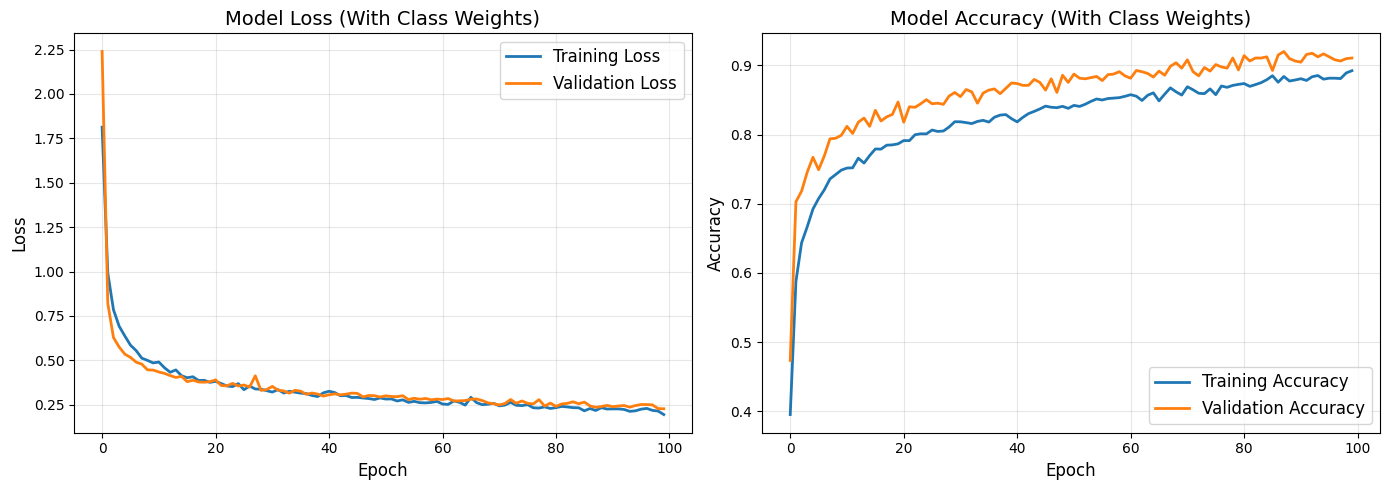


TEST SET EVALUATION
Test Loss:     0.1957
Test Accuracy: 0.9210 (92.10%)

PER-CLASS ACCURACY (With Class Weights)

Class                     Accuracy     Samples    Status    
-----------------------------------------------------------------
កាតាប                     100.00%     56          Good     
កាតាបស្ពាយក្រោយ            97.92%     48          Good     
កុំព្យូទ័រ                 98.51%     67          Good     
កៅអី                      100.00%     34          Good     
ក្ដារខៀន                   97.22%     36          Good     
ខ្មៅដៃ                    100.00%     57          Good     
ជ័រលុប                    100.00%     40          Good     
ដីស                        95.35%     43          Good     
តុ                        100.00%     40          Good     
ទឹកលុប                    100.00%     80          Good     
នាយករង                    100.00%     43          Good     
នាយិកា                    100.00%     63          Good     
បន្ទាត់                   100.00%    

c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6016 (\N{KHMER LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6070 (\N{KHMER VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6031 (\N{KHMER LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6036 (\N{KHMER LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6047 (\N{KHMER LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn

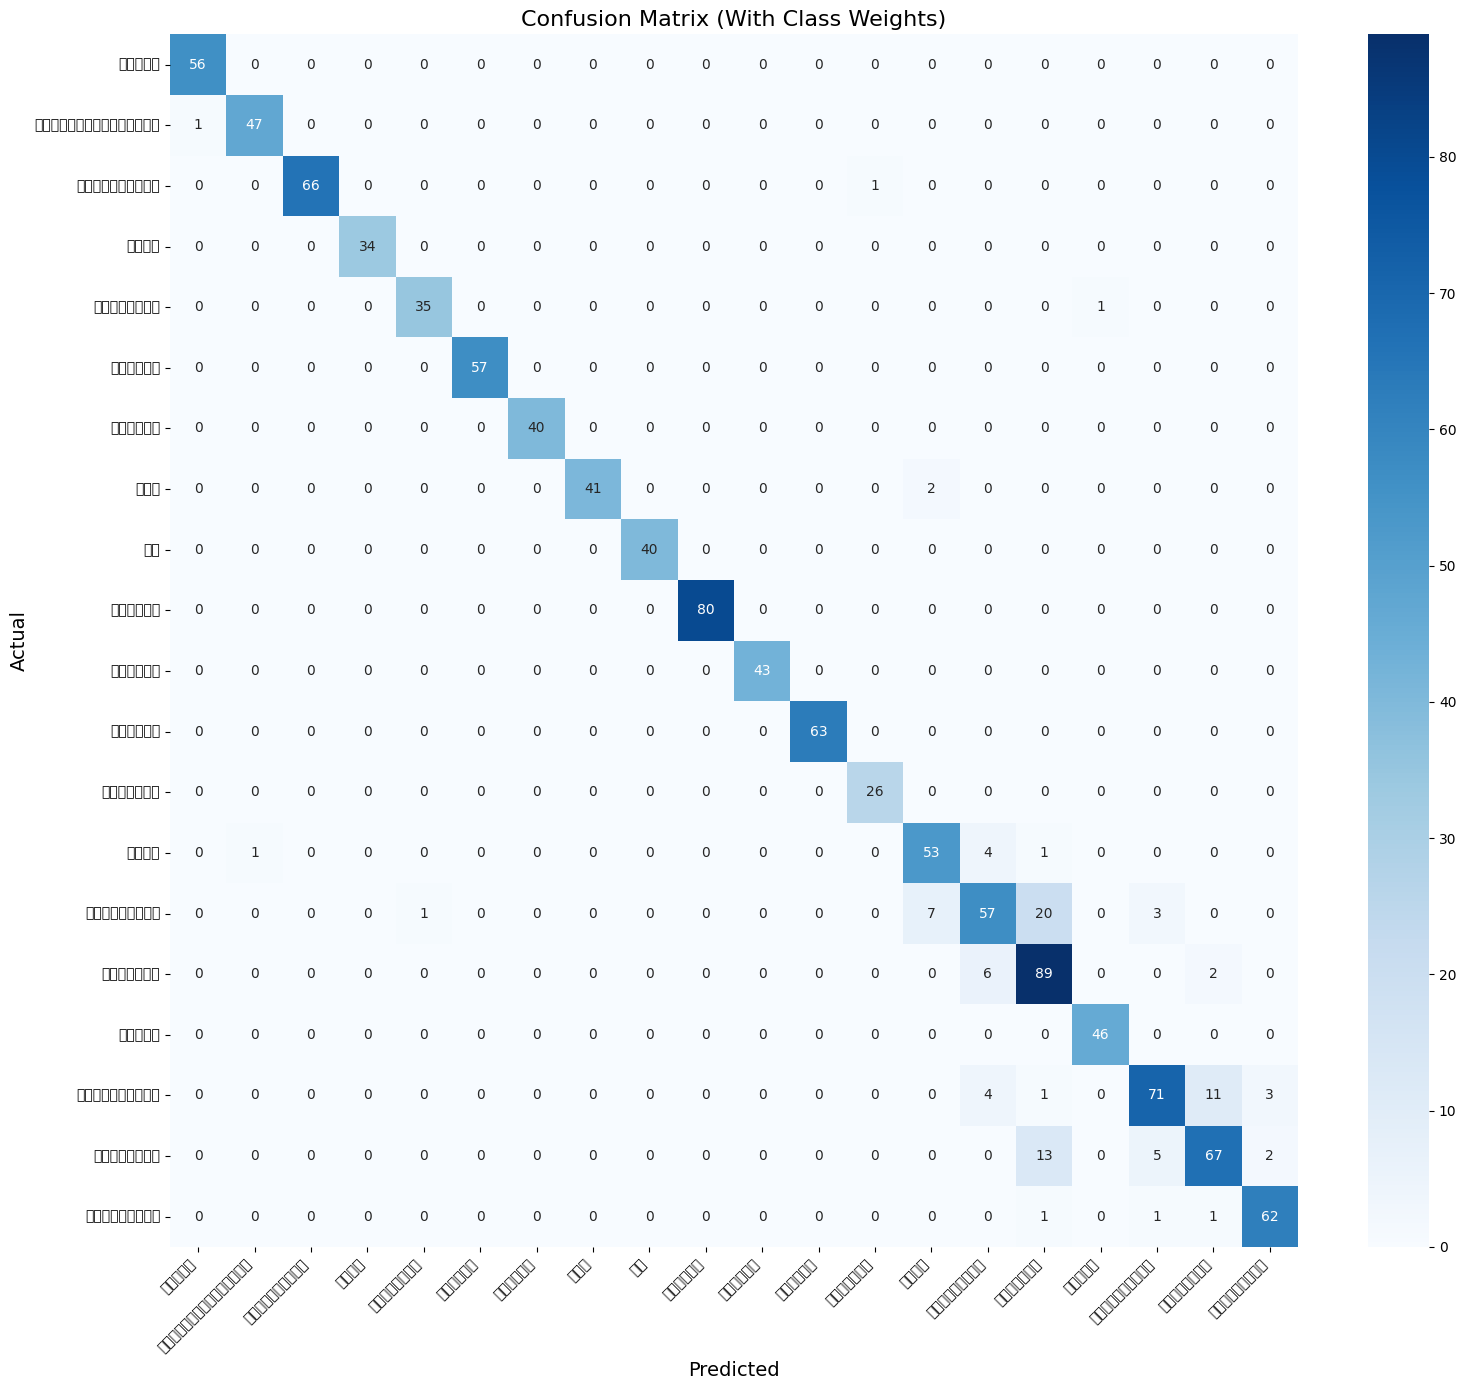


CLASSIFICATION REPORT
                 precision    recall  f1-score   support

          កាតាប       0.98      1.00      0.99        56
កាតាបស្ពាយក្រោយ       0.98      0.98      0.98        48
     កុំព្យូទ័រ       1.00      0.99      0.99        67
           កៅអី       1.00      1.00      1.00        34
       ក្ដារខៀន       0.97      0.97      0.97        36
         ខ្មៅដៃ       1.00      1.00      1.00        57
         ជ័រលុប       1.00      1.00      1.00        40
            ដីស       1.00      0.95      0.98        43
             តុ       1.00      1.00      1.00        40
         ទឹកលុប       1.00      1.00      1.00        80
         នាយករង       1.00      1.00      1.00        43
         នាយិកា       1.00      1.00      1.00        63
        បន្ទាត់       0.96      1.00      0.98        26
           ប៊ិក       0.85      0.90      0.88        59
      ប៊ិកក្រហម       0.80      0.65      0.72        88
        ប៊ិកខៀវ       0.71      0.92      0.80        97
       

In [5]:
# ============================================================
# VISUALIZE TRAINING HISTORY
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history):
    """
    Plot training and validation loss/accuracy
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss (With Class Weights)', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('Model Accuracy (With Class Weights)', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{Path(MODEL_SAVE_PATH).parent}/training_history.png", dpi=150)
    plt.show()

# Plot training history
plot_training_history(history)

# ============================================================
# EVALUATE ON TEST SET
# ============================================================

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ============================================================
# PER-CLASS ACCURACY (Most important for imbalanced data)
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "=" * 60)
print("PER-CLASS ACCURACY (With Class Weights)")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_classes)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print(f"\n{'Class':<25} {'Accuracy':<12} {'Samples':<10} {'Status':<10}")
print("-" * 65)

problematic = []
for i, class_name in enumerate(class_names):
    acc = class_accuracy[i]
    samples = np.sum(y_test == i)
    status = " Good" if acc >= 0.8 else " Okay" if acc >= 0.7 else " Poor"
    print(f"{class_name:<25} {acc*100:>6.2f}%     {samples:<10} {status:<10}")
    if acc < 0.7:
        problematic.append((class_name, acc))

# Show problematic classes
if problematic:
    print("\n" + "=" * 60)
    print(" PROBLEMATIC CLASSES (Below 70% Accuracy)")
    print("=" * 60)
    for class_name, acc in problematic:
        print(f"  - {class_name}: {acc*100:.2f}%")
    print("\n Consider:")
    print("  - Adding more samples for these classes")
    print("  - Trying data augmentation")
    print("  - Adjusting model architecture")
else:
    print("\n" + "=" * 60)
    print(" ALL CLASSES ABOVE 70% ACCURACY!")
    print("   Class weights are working well!")
    print("=" * 60)

# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (With Class Weights)', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{Path(MODEL_SAVE_PATH).parent}/confusion_matrix.png", dpi=150)
plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

## 6 Save model

In [6]:
# ============================================================
# SAVE MODEL AND HISTORY
# ============================================================

import pickle
import json 
# Save the model
model.save(MODEL_SAVE_PATH)
print(f"\n Model saved to: {MODEL_SAVE_PATH}")

# Save class names
# Save as pickle (for Python)
with open(f"{Path(MODEL_SAVE_PATH).parent}/class_names_lstm.pkl", 'wb') as f:
    pickle.dump(class_names, f)
print(f" Class names saved to: class_names_lstm.pkl")

# Save as JSON (more universal, readable)
with open(f"{Path(MODEL_SAVE_PATH).parent}/label_map_lstm.json", 'w', encoding='utf-8') as f:
    json.dump({
        str(i): class_name for i, class_name in enumerate(class_names)
    }, f, ensure_ascii=False, indent=2)
print(f" Label map saved to: label_map_lstm.json")

# Save training history
with open(f"{Path(MODEL_SAVE_PATH).parent}/training_history_lstm.pkl", 'wb') as f:
    pickle.dump(history.history, f)
print(f" Training history saved to: {Path(MODEL_SAVE_PATH).parent}/training_history_lstm.pkl")

print("\n" + "=" * 60)
print(" TRAINING COMPLETE!")
print("=" * 60)


 Model saved to: D:/uni/Intern-1-Project/ksl/models/lstm_best_model_v1.h5
 Class names saved to: class_names_lstm.pkl
 Label map saved to: label_map_lstm.json
 Training history saved to: D:\uni\Intern-1-Project\ksl\models/training_history_lstm.pkl

 TRAINING COMPLETE!
